In [1]:
# 导入常用库及设置中文显示
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
matplotlib.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题

d:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
d:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
d:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
d:\ProgramData\Anaconda3\envs\tensorflow210\lib\s

In [2]:
# 数据加载与映射函数

def load_and_map_data(code_csv, mapping_csv):
    """
    加载原始数据和映射表，完成大类（植被型）映射和编码。
    返回：df, mapping_df, class2veg, class2veg_num
    """
    df = pd.read_csv(code_csv, encoding='utf_8_sig')
    mapping_df = pd.read_csv(mapping_csv, encoding='utf_8_sig')
    mapping_df['Veg_Formation_num'] = mapping_df['Veg_Formation'].astype('category').cat.codes
    class2veg = dict(zip(mapping_df['ClassName'], mapping_df['Veg_Formation']))
    class2veg_num = dict(zip(mapping_df['ClassName'], mapping_df['Veg_Formation_num']))
    df['Veg_Formation'] = df['ClassName'].map(class2veg)
    df['Veg_Formation_num'] = df['ClassName'].map(class2veg_num)
    assert not df['Veg_Formation_num'].isnull().any(), "有ClassName未能映射到植被型编码"
    return df, mapping_df, class2veg, class2veg_num

# 路径请根据实际情况修改
code_csv = 'F:/TensorFlow/xinjiang/traindata20250626_2.csv'
mapping_csv = 'F:/TensorFlow/xinjiang/traindata20250626_2_class_mapping.csv'

df, mapping_df, class2veg, class2veg_num = load_and_map_data(code_csv, mapping_csv)
print('植被型名称与编码映射：')
print(dict(zip(mapping_df['Veg_Formation'], mapping_df['Veg_Formation_num'])))

植被型名称与编码映射：
{'丛生草类草原': 0, '半灌木与草本荒漠': 4, '农业植被': 2, '裸地': 8, '半乔木与灌木荒漠': 3, '根茎草类草甸': 7, '半灌木草原': 5, '杂类草草原': 6, '丛生草类草甸': 1}


## 大类分类模型训练与评估

In [3]:
def build_model(input_dim, num_classes):
    """构建多层全连接神经网络模型"""
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation='relu', input_dim=input_dim, kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

def get_xy(df, label_col, drop_cols):
    """特征与标签提取"""
    feature_cols = [col for col in df.columns if col not in drop_cols]
    x = df[feature_cols].values
    y = df[label_col].values
    return x, y

def train_eval_model(x_train, y_train, x_test, y_test, num_classes, verbose=0, model_name=None):
    """
    训练模型并评估，返回四项指标、各类别精度、模型对象。
    """
    y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
    model = build_model(x_train.shape[1], num_classes)
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    early_stopping = EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=8, verbose=0)
    history = model.fit(x_train, y_train_cat, epochs=200, batch_size=64, verbose=verbose, callbacks=[reduce_lr, early_stopping])
    # 绘制loss和acc曲线
    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    simple_name = None
    if model_name:
        import re
        m = re.search(r'([\u4e00-\u9fa5]+.*)$', model_name)
        simple_name = m.group(1) if m else model_name
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(history.history['loss'], color='y')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f"{simple_name if simple_name else ''}Loss", fontweight='bold')
    axes[1].plot(history.history[acc_key], color='g')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f"{simple_name if simple_name else ''}Accuracy", fontweight='bold')
    plt.tight_layout()
    plt.show()
    # 评估
    y_pred = model.predict(x_test).argmax(axis=1)
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    return [acc, precision, recall, f1], per_class_acc, model


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


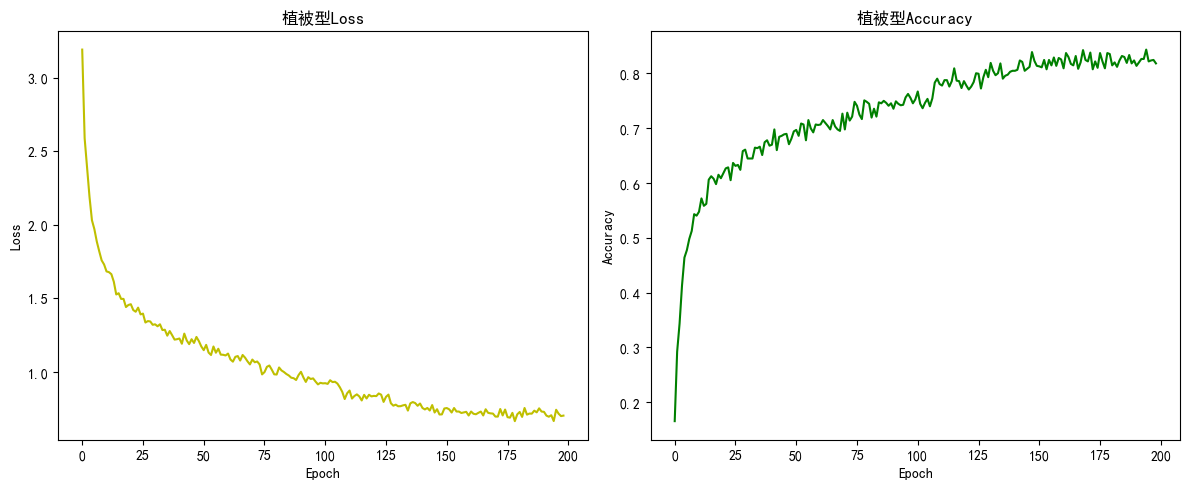

d:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\ipykernel_launcher.py:63: RuntimeWarning: invalid value encountered in true_divide


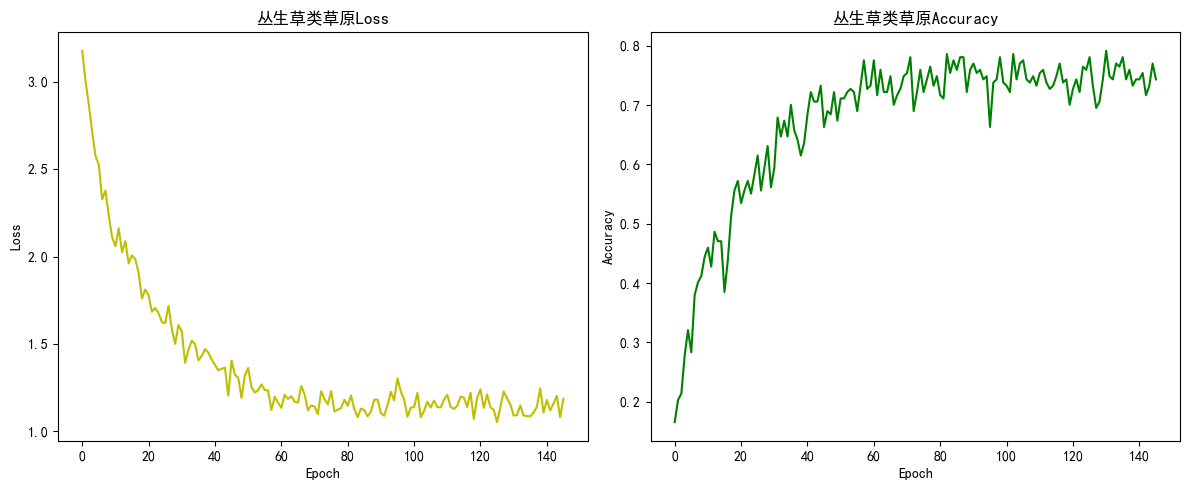

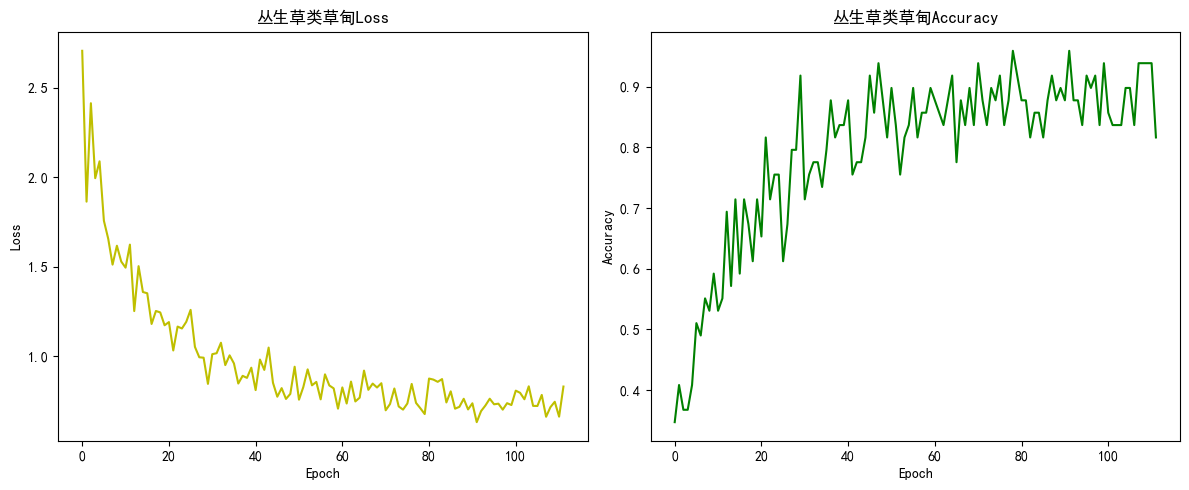

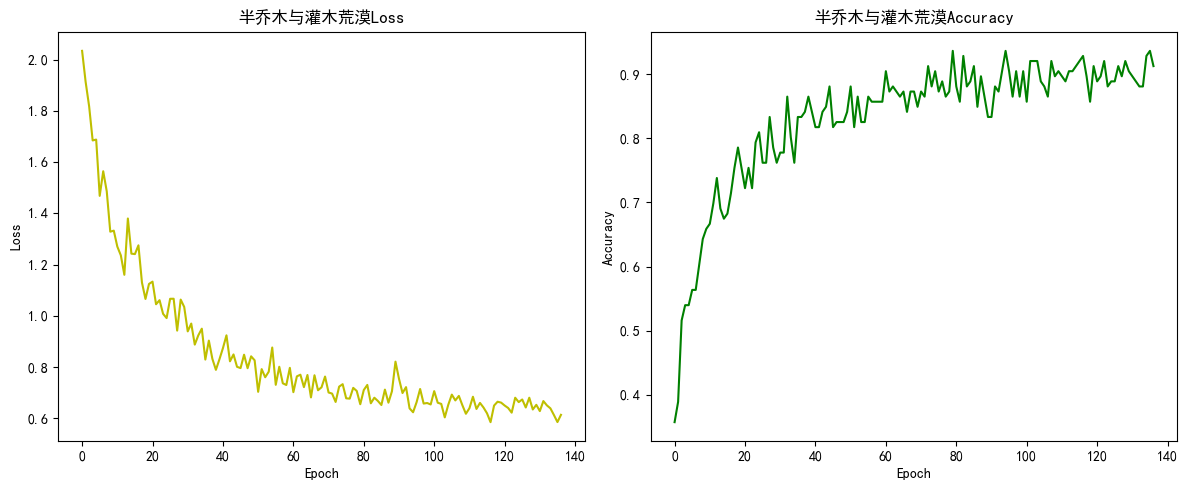

d:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\ipykernel_launcher.py:63: RuntimeWarning: invalid value encountered in true_divide


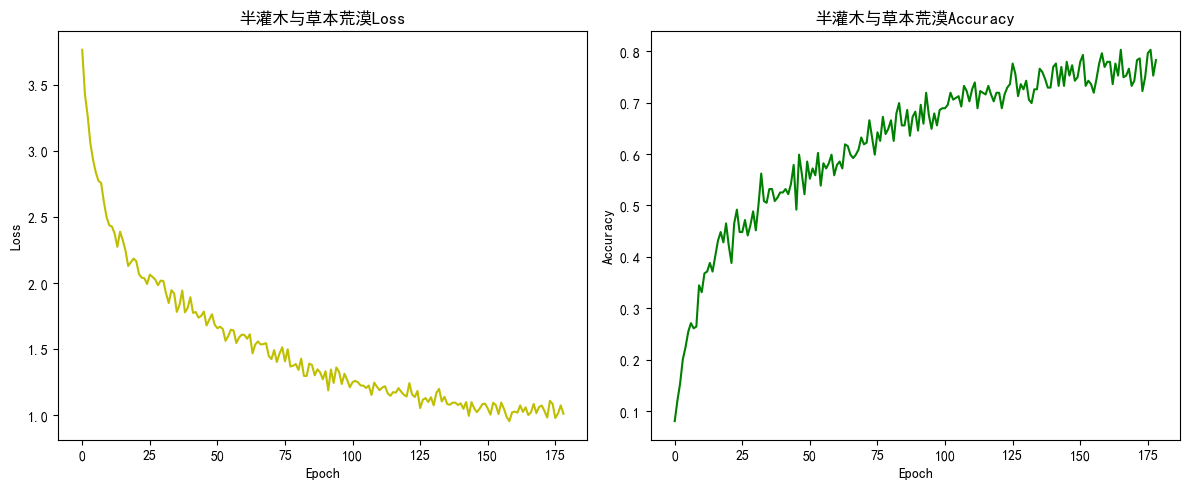

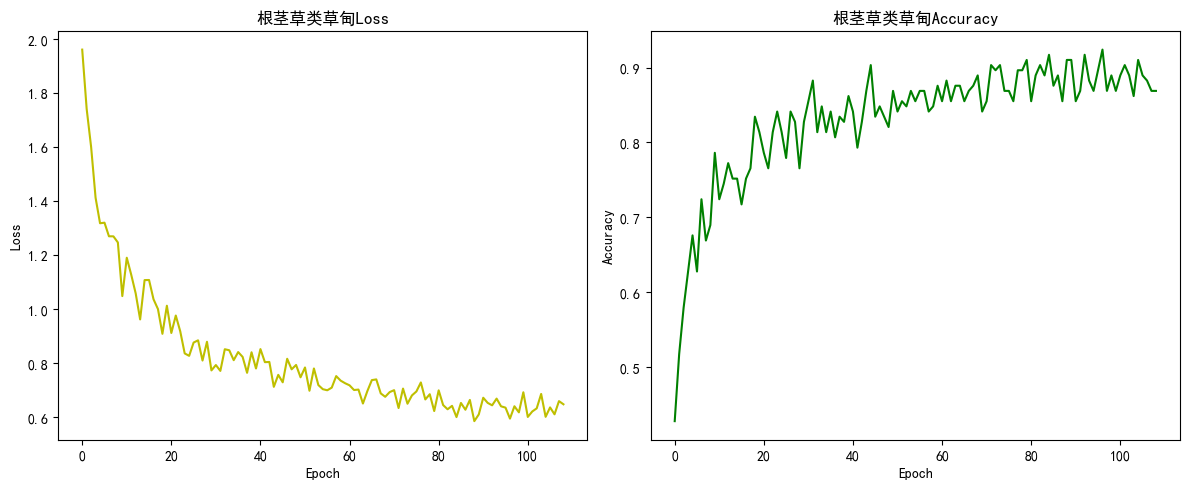

植被型（大类）验证集评估:
Accuracy: 0.6918, Precision: 0.5804, Recall: 0.5496, F1 Score: 0.5541
所有群系整体评估:
Accuracy: 0.6207, Precision: 0.5205, Recall: 0.5462, F1 Score: 0.5219


,植被型编码,植被型名称,群系编码,群系名称,群系精度
0,0,丛生草类草原,0,针茅属荒漠草原,0.800000
1,0,丛生草类草原,1,针茅属草原,0.600000
2,0,丛生草类草原,2,早熟禾属草甸,0.500000
3,0,丛生草类草原,3,紫花针茅草原,0.625000
4,0,丛生草类草原,4,新疆银穗草草原,0.000000
5,0,丛生草类草原,5,新疆银穗草、穗状寒生羊茅荒漠草原,0.500000
6,0,丛生草类草原,6,针茅属高寒草原,0.000000
7,1,丛生草类草甸,0,线叶嵩草草甸,0.000000
8,1,丛生草类草甸,1,嵩草属草甸,0.500000
9,1,丛生草类草甸,2,鸭茅草甸,1.000000


In [4]:
# 主流程：大类-小类分级训练与评估

def split_train_test(df, test_ratio=0.2, seed=None):
    """划分训练集和测试集"""
    idx = np.random.permutation(len(df)) if seed is None else np.random.RandomState(seed).permutation(len(df))
    split_idx = int(len(df) * (1 - test_ratio))
    train_df = df.iloc[idx[:split_idx]]
    test_df = df.iloc[idx[split_idx:]]
    return train_df, test_df

# 小类分级训练与评估

def train_and_eval_subclass(train_df, test_df, drop_cols, mapping_df):
    """
    针对每个大类，分别训练小类分类器并评估，返回整体指标和各小类精度表。
    """
    all_true, all_pred, sub_acc_rows = [], [], []
    veg_label_map = dict(zip(mapping_df['Veg_Formation_num'], mapping_df['Veg_Formation']))
    veg_nums = sorted(train_df['Veg_Formation_num'].unique())
    for idx, veg_num in enumerate(veg_nums):
        veg_name = veg_label_map.get(veg_num, str(veg_num))
        sub_test = test_df[test_df['Veg_Formation_num_pred'] == veg_num]
        sub_train = train_df[train_df['Veg_Formation_num'] == veg_num]
        if len(sub_train) < 2 or len(sub_test) < 1:
            continue
        sub_class_names = sub_train['ClassName'].unique()
        class_name2num = {name: i for i, name in enumerate(sub_class_names)}
        sub_train = sub_train.copy()
        sub_test = sub_test.copy()
        sub_train['sub_num'] = sub_train['ClassName'].map(class_name2num)
        sub_test['sub_num'] = sub_test['ClassName'].map(class_name2num)
        sub_test = sub_test[~sub_test['sub_num'].isnull()]
        if len(class_name2num) < 2 or len(sub_test) < 1:
            continue
        feature_cols = [col for col in sub_train.columns if col not in drop_cols + ['sub_num']]
        feature_cols = [col for col in feature_cols if col in sub_test.columns]
        x_train_sub = sub_train[feature_cols].values
        y_train_sub = sub_train['sub_num'].values
        x_test_sub = sub_test[feature_cols].values
        y_test_sub = sub_test['sub_num'].values
        num_sub_classes = len(class_name2num)
        _, _, sub_model = train_eval_model(x_train_sub, y_train_sub, x_test_sub, y_test_sub, num_sub_classes, model_name=f'{veg_name}')
        y_pred_sub = sub_model.predict(x_test_sub).argmax(axis=1)
        all_true.extend(y_test_sub)
        all_pred.extend(y_pred_sub)
        cm = confusion_matrix(y_test_sub, y_pred_sub, labels=np.arange(num_sub_classes))
        with np.errstate(divide='ignore', invalid='ignore'):
            per_class_acc = np.where(cm.sum(axis=1) == 0, np.nan, cm.diagonal() / cm.sum(axis=1))
        for cname, idx2 in class_name2num.items():
            sub_acc_rows.append({
                '植被型编码': veg_num,
                '植被型名称': veg_name,
                '群系编码': idx2,
                '群系名称': cname,
                '群系精度': per_class_acc[idx2] if idx2 < len(per_class_acc) else None
            })
    return all_true, all_pred, sub_acc_rows

# ========== 主流程 ========== #

drop_cols = ['className', 'ClassName', 'num', 'Veg_Formation', 'Veg_Formation_num']
train_df, test_df = split_train_test(df, test_ratio=0.2)

# 大类分类
x_train, y_train = get_xy(train_df, 'Veg_Formation_num', drop_cols)
x_test, y_test = get_xy(test_df, 'Veg_Formation_num', drop_cols)
num_veg_classes = df['Veg_Formation_num'].nunique()
_, _, veg_model = train_eval_model(x_train, y_train, x_test, y_test, num_veg_classes, model_name='植被型')

# 预测大类标签
veg_label_map = dict(zip(mapping_df['Veg_Formation_num'], mapping_df['Veg_Formation']))
test_df = test_df.copy()
test_df['Veg_Formation_num_pred'] = veg_model.predict(x_test).argmax(axis=1)

# 小类分级训练与评估
all_true, all_pred, sub_acc_rows = train_and_eval_subclass(train_df, test_df, drop_cols, mapping_df)

# 大类验证集评估
veg_pred = veg_model.predict(x_test).argmax(axis=1)
veg_acc = accuracy_score(y_test, veg_pred)
veg_precision = precision_score(y_test, veg_pred, average='macro', zero_division=0)
veg_recall = recall_score(y_test, veg_pred, average='macro', zero_division=0)
veg_f1 = f1_score(y_test, veg_pred, average='macro', zero_division=0)
print('植被型（大类）验证集评估:')
print(f'Accuracy: {veg_acc:.4f}, Precision: {veg_precision:.4f}, Recall: {veg_recall:.4f}, F1 Score: {veg_f1:.4f}')

# 所有小类整体四项指标
if all_true and all_pred:
    global_acc = accuracy_score(all_true, all_pred)
    global_precision = precision_score(all_true, all_pred, average='macro', zero_division=0)
    global_recall = recall_score(all_true, all_pred, average='macro', zero_division=0)
    global_f1 = f1_score(all_true, all_pred, average='macro', zero_division=0)
    print('所有群系整体评估:')
    print(f'Accuracy: {global_acc:.4f}, Precision: {global_precision:.4f}, Recall: {global_recall:.4f}, F1 Score: {global_f1:.4f}')
    # 各小类精度表
    df_sub_acc = pd.DataFrame(sub_acc_rows, columns=['植被型编码', '植被型名称', '群系编码', '群系名称', '群系精度'])
    display(df_sub_acc)
else:
    print('无有效小类评估结果。')